# Implementation Roadmap
## LLM as a judge
### Must-have (ship first)
- **Strict JSON schema + retry-on-fail**  
  Ensures well-formed, consistent outputs.  

- **Multi-trace CoT (k=3–5) + self-confidence**  
  Generate multiple reasoning traces; each trace provides its own confidence score.  

- **Weighted voting by self-confidence**  
  Aggregate values using confidence weights instead of plain majority.  

- **Evidence grounding (span linking)**  
  Judge must cite exact supporting text spans; missing evidence → lower confidence.  

- **Domain validators (hard/soft rules)**  
  - Dates follow expected formats  
  - VAT ID / IBAN checksum validation  
  - `Gross ≈ Net + VAT` (within tolerance)  
  - Currency whitelist checks  

- **Per-field calibration**  
  Map raw confidence to true correctness probability (e.g., isotonic or temperature scaling).  

- **Acceptance policy**  
  Apply per-field thresholds; for documents, require all critical fields to pass.  

- **Auditing & provenance**  
  Store chosen value, calibrated confidence, cited spans, validator outcomes, and reasoning traces.  

---

### High-impact add-ons (still no training)
- **Dual-phase reasoning**  
  1. Solution reasoning → generate answer  
  2. Confidence reasoning → judge and verbalize confidence bin (0–9 or 0–1)  

- **Difficulty-aware sampling**  
  Use vote dispersion or evidence quality to stop early on easy fields or sample more traces for hard ones.  

- **Cross-judge diversity (multiple rubrics)**  
  Run the same model with different judging rubrics and combine results:  
  - *Format-strict judge*: strict regex/format checks (e.g., dates, VAT IDs)  
  - *Arithmetic-strict judge*: check totals and sums (e.g., Gross vs. Net + VAT)  
  - *Evidence-strict judge*: require supporting spans near relevant anchors (e.g., “VAT”, “Total”)  

- **Few-shot bank (prompt-only)**  
  Maintain a curated set of vendor/layout examples; update as new reviewed cases are added.  

---

### Ops & monitoring
- **Coverage vs. accuracy dashboards**  
  Track Brier, ECE, NLL, AUROC; monitor auto-accept vs. review rates.  

- **Periodic recalibration**  
  Refresh calibration mappings as new reviewed cases arrive.  

- **Fail-safes**  
  If JSON invalid or confidence unstable → deterministic re-ask at temperature=0; else route to review.  


<style>
open { color: Red }
inprogress { color: Yellow }
done { color: Green; text-decoration: line-through }
</style>

# First steps
To start things off, we need to build a simple LLM-as-a-Judge (LaaJ) setup<br>
For this we need to do prepare the following:
- <done>Access to the Azure hosted GPT5-mini</done>
- <inprogress>Access to the data located on the NAS</inprogress>

Then we need to force the LLM to create multiple reasoning paths for one input.<br>
- <done>Actively encourage the LLM to perform "slow thinking" and prepare a json output schema the data needs to fit in.</done><br>
- <done>Implement a retry option (with amount of retries as a parameter) to catch LLM errors.</done><br>
- <open>Peform validity checks for produced outputs (Valid VAT layout, isNumber for amounts, ...). If these checks fail --> confidence decrease / set to 0.</open><br>
- <done>Query the LLM to rate its own output using numeric and written bins (10 bins, [0.0; 0.1], [0.1; 0.2], ...)</done><br>
- <done>Implement weighted majority voting based on confidence (Borda voting with exponent)</done><br>

<done>Visualize the results of perceived confidence and actual correctness in a bar chart (should be x=y for perfect prediction)</done><br>


# LLM Setup

In [64]:
# --- setup: remove retries, unused vars, fix concurrent name, simpler mkdir ---
from datetime import datetime
import os
from pathlib import Path
from dotenv import load_dotenv
from openai import AsyncOpenAI
import logging
import json

load_dotenv(override=True)

DOCUMENT_STORAGE = Path(os.getenv("DOCUMENT_STORAGE"))
TIMESTAMP = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

API_KEY = os.getenv("AZURE_OPENAI_API_KEY")
ENDPOINT = os.getenv("AZURE_OPENAI_ENDPOINT")
DEPLOYMENT_NAME = os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME")

client = AsyncOpenAI(api_key=API_KEY, base_url=ENDPOINT)

CONCURRENT_TASKS = 15  # fixed typo

# # Pricing (EUR per 1M tokens) for GPT-5-mini
# PRICE_INPUT_EUR_PER_MTOK = 0.22
# PRICE_CACHED_INPUT_EUR_PER_MTOK = 0.03
# PRICE_OUTPUT_EUR_PER_MTOK = 1.73

# Pricing (EUR per 1M tokens) for GPT-5-nano
PRICE_INPUT_EUR_PER_MTOK = 0.05
PRICE_CACHED_INPUT_EUR_PER_MTOK = 0.01
PRICE_OUTPUT_EUR_PER_MTOK = 0.35

logging_path = Path("../Logs")
logging_path.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    filename=f"{logging_path}/{DEPLOYMENT_NAME}_{TIMESTAMP}.log",
    filemode="a",
    format="%(asctime)s - %(levelname)s - %(message)s",
    level=logging.INFO,
    force=True,
)
for noisy in ["httpx", "openai", "azure", "urllib3"]:
    logging.getLogger(noisy).setLevel(logging.WARNING)

with open("../Prompts/system_prompt.txt", "r", encoding="utf-8") as f:
    system_prompt = f.read()
with open("../Prompts/schema.json", "r", encoding="utf-8") as f:
    schema = json.load(f)
formatted_schema = json.dumps(schema, indent=2)
system_prompt = system_prompt.replace("formatted_schema_representation", formatted_schema)


# Helper Functions

## Fuzzy Comparison

In [65]:
import re
from typing import Any, Optional

COMPARE_FIELDS = [
    "Sender.VatId",
    "GrandTotal.Amount",
    "Net.Amount",
    "Vat.Amount",
    "Vat.Rate",
    "Invoice.Date",
]

NUMERIC_FIELDS = {
    "GrandTotal.Amount",
    "Net.Amount",
    "Vat.Amount",
    "Vat.Rate",
}


_TRAILING_RE = re.compile(r"[ \t\r\n\.,;:\-\u2013\u2014\u2011]+$")  # remove trailing whitespace, punctuation, and hyphen-like dashes

def strip_trailing_punct(x: Any) -> Optional[str]:
    if x is None:
        return None
    s = str(x).strip()
    if not s:
        return None
    return _TRAILING_RE.sub("", s)

def parse_number(x: Any) -> Optional[float]:
    """
    Improved numeric parsing:
    - Rightmost of ',' or '.' is treated as the decimal separator.
    """
    s = strip_trailing_punct(x)
    if s is None:
        return None

    # keep only digits, separators, minus
    s = re.sub(r"[^0-9,.\-]", "", s)
    if not s:
        return None

    last_dot = s.rfind(".")
    last_comma = s.rfind(",")

    if last_dot != -1 and last_comma != -1:
        # both present: rightmost decides decimal
        if last_comma > last_dot:
            # comma is decimal, dots are thousands
            s = s.replace(".", "")
            s = s.replace(",", ".")
        else:
            # dot is decimal, commas are thousands
            s = s.replace(",", "")
    elif last_comma != -1:
        # only comma present -> decimal comma
        s = s.replace(".", "")  # any stray dots treated as thousands
        s = s.replace(",", ".")

    try:
        val = float(s)
    except ValueError:
        return None

    return val


def normalize_value(field: str, value: Any):
    if field in NUMERIC_FIELDS:
        return parse_number(value)
    # Special-case: for VAT IDs, remove all internal whitespace before compare
    if field == "Sender.VatId":
        s = strip_trailing_punct(value)
        if s is None:
            return None
        return re.sub(r"\s+", "", s)
    # non-numeric: only remove trailing whitespace/punctuation
    return strip_trailing_punct(value)


def _round_numeric(val):
    if val is None:
        return None
    return round(float(val), 2)

def _normalize_element(field: str, value: Any):
    v = normalize_value(field, value)
    if field in NUMERIC_FIELDS:
        v = _round_numeric(v)
    return v

def normalize_for_compare(field: str, value):
    """Normalize values for comparison.
    - For numeric fields: parse and round
    - For text: trim trailing punctuation/whitespace; special-case VAT removes internal whitespace
    - For lists: apply element-wise normalization and drop Nones/empties
    """
    if isinstance(value, list):
        normed_list = []
        for item in value:
            nv = _normalize_element(field, item)
            if nv is None or (isinstance(nv, str) and nv == ""):
                continue
            normed_list.append(nv)
        return normed_list
    return _normalize_element(field, value)


In [118]:
import time
import asyncio
from collections import defaultdict, Counter

from openai import BadRequestError

async def _timed_request(timeout_sec: float = 60, **kwargs):
    start = time.time()
    try:
        resp = await asyncio.wait_for(client.responses.create(**kwargs), timeout=timeout_sec)
    except (asyncio.TimeoutError, BadRequestError):
        runtime = round(time.time() - start, 2)
        return None, {
            "runtime_sec": runtime,
            "input_tokens": None,
            "cached_input_tokens": None,
            "output_tokens": None,
            "total_tokens": None,
            "timed_out": True,
        }
    runtime = round(time.time() - start, 2)
    usage = getattr(resp, "usage", None)
    ptd = getattr(usage, "prompt_tokens_details", None) if usage else None
    cached = getattr(ptd, "cached_tokens", None) if ptd else None
    return resp, {
        "runtime_sec": runtime,
        "input_tokens": getattr(usage, "input_tokens", None),
        "cached_input_tokens": cached,  # now correctly populated when supported
        "output_tokens": getattr(usage, "output_tokens", None),
        "total_tokens": getattr(usage, "total_tokens", None),
        "timed_out": False,
    }

# --- helper: verify previous_response_id is indexed, with exponential backoff ---
async def _wait_until_indexed(prev_id: str, retries: int = 4, base_delay: float = 0.25) -> bool:
    prev_id = str(prev_id)
    for i in range(retries):
        try:
            # succeeds when the response is visible to the service
            await client.responses.retrieve(prev_id)
            return True
        except Exception:
            await asyncio.sleep(base_delay * (2 ** i))
    return False

# --- helper: try chaining; on 400 prev-id-not-found, auto-fallback to inline context ---
async def _request_with_verified_chain(*, step_label: str, previous_response, inline_context: str | None, **kwargs):
    prev_id = getattr(previous_response, "id", None)
    if prev_id:
        ok = await _wait_until_indexed(prev_id)
        if ok:
            try:
                return await _timed_request(previous_response_id=str(prev_id), **kwargs)
            except BadRequestError as e:
                msg = str(e)
                if "previous_response_id" in msg and "not found" in msg:
                    print(f"[WARN] {step_label}: previous_response_id not found -> {prev_id}. Falling back to inline context.")
                else:
                    raise
        else:
            print(f"[WARN] {step_label}: previous_response_id not indexed -> {prev_id}. Falling back to inline context.")

    # Fallback: append prior notes directly to input and call without chaining
    new_kwargs = dict(kwargs)
    if inline_context:
        new_kwargs["input"] = f"{kwargs.get('input','')}\n\n=== CONTEXT FROM PREVIOUS STEP ===\n{inline_context}"
    return await _timed_request(**new_kwargs)



CONFIDENCE_CLASSES = [
    "Almost no chance",
    "Highly unlikely",
    "Chances are slight",
    "Unlikely",
    "Less than even",
    "Better than even",
    "Likely",
    "Very good chance",
    "Highly likely",
    "Almost certain"
]

def score_to_verbal(score: float) -> str:
    s = 0.0 if score is None else float(score)
    s = max(0.0, min(1.0, s))
    bounds = [0.00, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
    idx = max(i for i, b in enumerate(bounds) if s >= b)
    return CONFIDENCE_CLASSES[idx]


def _extract_reasoning_text(resp) -> str:
    chunks = []
    for item in getattr(resp, "output", []) or []:
        if getattr(item, "type", "") == "reasoning":
            summary = getattr(item, "summary", None)
            if isinstance(summary, list):
                for seg in summary:
                    t = getattr(seg, "text", None)
                    if t:
                        chunks.append(t)
            for seg in getattr(item, "content", []) or []:
                t = getattr(seg, "text", None)
                if t:
                    chunks.append(t)
    if chunks:
        return "\n".join(chunks).strip()
    return getattr(resp, "output_text", "") or ""

def _coerce_answer_dict(ans: dict) -> dict:
    if isinstance(ans, dict) and "properties" in ans and "values" in ans:
        v = ans.get("values")
        return v if isinstance(v, dict) else ans
    return ans if isinstance(ans, dict) else {}



def _gt_path_for_txt(txt_path):
    p = Path(txt_path)
    stem_id = p.stem.split("_")[0]  
    return sorted(p.parent.glob(f"{stem_id}*.json"))[0]


def _norm_scalar(v):
    if v is None:
        return ""
    if isinstance(v, (int, float, bool)):
        return str(v)
    return str(v).strip()


def _flatten_gt(gt: dict) -> dict:
    out = defaultdict(list)
    for node in gt.get("DocumentEssentials", []) or []:
        label = node.get("Label")
        items = node.get("Items")
        if items:
            # e.g., "Vat.Item" group: collect sub-labels into lists
            for sub in items:
                sub_label = sub.get("Label")
                sub_text = sub.get("Text")
                if sub_label:
                    out[sub_label].append(_norm_scalar(sub_text))
        else:
            text = node.get("Text")
            if label:
                out[label].append(_norm_scalar(text))
    # collapse singletons to scalars
    flat = {}
    for k, vals in out.items():
        vals = [v for v in vals if v != ""]
        flat[k] = vals[0] if len(vals) == 1 else vals
    return flat

def _to_multiset(v):
    if isinstance(v, list):
        return Counter(v)
    return Counter([v])

def _dedupe_preserve_order(seq):
    seen = set()
    out = []
    for item in seq:
        key = item
        if not isinstance(item, (str, int, float, bool)) and item is not None:
            try:
                key = json.dumps(item, sort_keys=True, ensure_ascii=False)
            except Exception:
                key = str(item)
        if key in seen:
            continue
        seen.add(key)
        out.append(item)
    return out

def compare_with_ground_truth(answer_dict: dict, txt_path: str | Path):
    gt_path = _gt_path_for_txt(txt_path)
    if not Path(gt_path).exists():
        return {
            "ground_truth_path": str(gt_path),
            "per_field": {},
            "summary": {"matched": 0, "total": 0, "all_match": False, "note": "ground truth not found"},
        }

    gt_json = json.loads(Path(gt_path).read_text(encoding="utf-8"))
    gt_flat = _flatten_gt(gt_json)

    fields_to_check = [f for f in COMPARE_FIELDS if f in gt_flat or f in answer_dict]
    per_field = {}
    num_matched = 0

    for field in fields_to_check:
        llm_raw = answer_dict.get(field, None)
        gt_raw = gt_flat.get(field, None)

        # Skip if GT is explicitly missing: []
        if isinstance(gt_raw, list) and len(gt_raw) == 0:
            continue

        llm_norm = normalize_for_compare(field, llm_raw)
        gt_norm = normalize_for_compare(field, gt_raw)

        # Also skip if GT normalizes to an empty list
        if isinstance(gt_norm, list) and len(gt_norm) == 0:
            continue

        if isinstance(gt_norm, list):
            gt_norm = _dedupe_preserve_order(gt_norm)

        if isinstance(llm_norm, list) or isinstance(gt_norm, list):
            is_match = _to_multiset(llm_norm) == _to_multiset(gt_norm)
        else:
            is_match = llm_norm == gt_norm

        if is_match:
            num_matched += 1

        per_field[field] = [is_match, llm_raw, gt_raw]

    total = len(per_field)
    return {
        "ground_truth_path": str(gt_path),
        "per_field": per_field,
        "summary": {"matched": num_matched, "total": total, "all_match": num_matched == total},
    }



# Test Reasoning path setup

In [67]:
from pathlib import Path
import json
from datetime import datetime

def _postprocess_final_payload(payload: dict) -> dict:
    """
    Expecting payload shape:
    {
      "answer": {...},                       # dict conforming to your schema
      "confidence": {"field.path": float}    # 0..1 per field that appears in 'answer'
    }
    Returns lean record with numeric + verbal per field.
    """
    answer = _coerce_answer_dict(payload.get("answer", {}))
    conf_num = payload.get("confidence", {}) or {}

    # Build verbal per field for fields present in numeric dict
    conf_verbal = {k: score_to_verbal(v) for k, v in conf_num.items()}

    return {
        "answer": answer,
        "confidence_numeric": conf_num,
        "confidence_verbal": conf_verbal,
    }

async def run_three_step_invoice_with_reasoning(invoice_txt_path: str, output_dir: Path):
    text = Path(invoice_txt_path).read_text(encoding="utf-8")

    # Step 1 — SOLUTION REASONING
    resp1, log1 = await _timed_request(
        model=DEPLOYMENT_NAME,
        instructions=system_prompt,
        input=(
            "Step 1 — SOLUTION REASONING:\n"
            "Reason step by step to extract the structured invoice data from the text below. "
            "Use slow thinking (explore alternatives, verify fields). "
            "Do NOT output the final answer yet.\n\n"
            f"--- INVOICE TEXT START ---\n{text}\n--- INVOICE TEXT END ---"
        ),
        reasoning={"effort": "low"},
        max_output_tokens=4000,
        text={"verbosity": "low"},
        user="laaj-batch",
        store=True,  # must be stored so retrieve() can see it
    )
    if resp1 is None:
        return None
    step1_notes = _extract_reasoning_text(resp1)

    # Step 2 — CONFIDENCE REASONING (verify + chain, else inline step1_notes)
    resp2, log2 = await _request_with_verified_chain(
        step_label="STEP2",
        previous_response=resp1,
        inline_context=step1_notes,
        model=DEPLOYMENT_NAME,
        instructions=system_prompt,
        input=(
            "Step 2 — CONFIDENCE REASONING:\n"
            "Evaluate, step by step, how likely each extracted field is correct, based on internal consistency "
            "and evidence in the text. Do NOT output the final answer yet."
        ),
        reasoning={"effort": "low"},
        max_output_tokens=2000,
        text={"verbosity": "low"},
        user="laaj-batch",
        store=True,  # store so step 3 can chain to it
    )
    if resp2 is None:
        return None
    step2_notes = _extract_reasoning_text(resp2)

    # Step 3 — FINAL JSON (verify + chain to step2; fallback inlines step1+step2 notes)
    inline_both = (
        f"=== CONTEXT FROM STEP 1 ===\n{step1_notes}\n\n"
        f"=== CONTEXT FROM STEP 2 ===\n{step2_notes}"
    )
    resp3, log3 = await _request_with_verified_chain(
        step_label="STEP3",
        previous_response=resp2,
        inline_context=inline_both,
        model=DEPLOYMENT_NAME,
        instructions=system_prompt,
        input=(
            "Step 3 — FINAL OUTPUT:\n"
            "Return ONLY a single valid JSON object with this structure and nothing else:\n"
            "{\n"
            '  "answer": <your final extracted invoice data strictly following this schema: '
            f"{json.dumps(schema)}"
            ">,\n"
            '  "confidence": {\n'
            "    // For every field you output in 'answer', provide a numeric confidence in [0,1].\n"
            '    // Use the exact same field keys as in "answer". For nested fields, use dot-notation keys.\n'
            '    // Example: "Net.Amount": 0.82\n'
            "  }\n"
            "}\n"
        ),
        reasoning={"effort": "low"},
        max_output_tokens=2000,
        text={"verbosity": "low"},
        user="laaj-batch",
        store=True,
    )
    if resp3 is None:
        return None

    try:
        payload = json.loads(resp3.output_text)
    except Exception:
        return None

    processed = _postprocess_final_payload(payload)
    evaluation = compare_with_ground_truth(processed['answer'], invoice_txt_path)

    itok = (log1.get("input_tokens") or 0) + (log2.get("input_tokens") or 0) + (log3.get("input_tokens") or 0)
    itok_cached = (log1.get("cached_input_tokens") or 0) + (log2.get("cached_input_tokens") or 0) + (log3.get("cached_input_tokens") or 0)
    otok = (log1.get("output_tokens") or 0) + (log2.get("output_tokens") or 0) + (log3.get("output_tokens") or 0)

    billable_input = max(0, itok - itok_cached)
    cost_eur = (
        (billable_input / 1_000_000.0) * PRICE_INPUT_EUR_PER_MTOK
        + (itok_cached / 1_000_000.0) * PRICE_CACHED_INPUT_EUR_PER_MTOK
        + (otok / 1_000_000.0) * PRICE_OUTPUT_EUR_PER_MTOK
    )

    lean_record = {
        "input_path": str(invoice_txt_path),
        "answer": processed["answer"],
        "confidence_numeric": processed["confidence_numeric"],
        "confidence_verbal": processed["confidence_verbal"],
        "reasoning": {"step1": step1_notes, "step2": step2_notes},
        "llm_logs": {"step1": log1, "step2": log2, "step3": log3},
        "evaluation": evaluation,
        "cost": {
            "input_tokens": itok,
            "cached_input_tokens": itok_cached,
            "output_tokens": otok,
            "eur_estimate": round(cost_eur, 6),
        },
    }

    out_path = output_dir / (Path(invoice_txt_path).stem + ".json")
    out_path.write_text(json.dumps(lean_record, ensure_ascii=False, indent=2), encoding="utf-8")
    return lean_record



# Add weighted majority voting

In [ ]:
# Concurrent weighted majority voting with bounded parallelism
import asyncio
from collections import defaultdict
import json
from pathlib import Path

def _key(v):
    # hashable key for dict/list/float/string values
    if isinstance(v, (str, int, float, bool)) or v is None:
        return v
    return json.dumps(v, sort_keys=True, ensure_ascii=False)

def _weighted_majority(flat_runs):
    consensus_result = {}
    debug_info = {}

    all_fields = set().union(*[r["answer"].keys() for r in flat_runs])
    for field in all_fields:
        sum_confidence = defaultdict(float)
        vote_count = defaultdict(int)

        for run in flat_runs:
            if field in run["answer"]:
                value = run["answer"][field]
                confidence = float(run["confidence_numeric"].get(field, 1.0) or 1.0)
                key = _key(value)
                sum_confidence[key] += confidence
                vote_count[key] += 1

        if sum_confidence:
            # pick value with max accumulated confidence; tie-break by count
            best_key = max(sum_confidence, key=lambda k: (sum_confidence[k], vote_count[k]))
            try:
                best_value = json.loads(best_key)
            except Exception:
                best_value = best_key

            consensus_result[field] = {
                "value": best_value,
                "sum_confidence": round(sum_confidence[best_key], 2),
                "vote_count": vote_count[best_key],
                "avg_confidence": round(sum_confidence[best_key] / max(1, vote_count[best_key]), 2),
            }
            debug_info[field] = {
                "sum_conf_per_value": {k: round(v, 2) for k, v in sum_confidence.items()},
                "counts": dict(vote_count),
            }

    return consensus_result, debug_info

async def run_self_consistent_invoice(
    invoice_txt_path: str,
    n_paths: int = 5,
    sem: asyncio.Semaphore | None = None,
    base_dir: Path | None = None,
):
    stem = Path(invoice_txt_path).stem                          
    file_id = stem.split("_")[0]                                

    # Use provided base_dir or create a local one (only for standalone usage)
    root_out = base_dir or Path(f"../Output/{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}")
    root_out.mkdir(parents=True, exist_ok=True)

    # Per-file subfolder by ID
    file_dir = root_out / file_id
    file_dir.mkdir(parents=True, exist_ok=True)

    local_sem = sem or asyncio.Semaphore(CONCURRENT_TASKS)

    async def _bounded_run(out_dir: Path):
        async with local_sem:
            return await run_three_step_invoice_with_reasoning(invoice_txt_path, out_dir)

    tasks = []
    for i in range(n_paths):
        out_dir = file_dir / f"rep_{i+1}"
        out_dir.mkdir(parents=True, exist_ok=True)
        tasks.append(asyncio.create_task(_bounded_run(out_dir)))

    runs = await asyncio.gather(*tasks)
    runs = [r for r in runs if r is not None]  # drop failed traces

    flat_runs = [{"answer": r["answer"], "confidence_numeric": r.get("confidence_numeric", {})} for r in runs]
    final_answer, debug = _weighted_majority(flat_runs)

    # Add correctness assesment to consensus
    answer_values = {
        f: (e.get("value") if isinstance(e, dict) else e)
        for f, e in final_answer.items()
    }
    try:
        evaluation = compare_with_ground_truth(answer_values, invoice_txt_path)
        per_field_eval = evaluation.get("per_field", {}) or {}
        for f, entry in final_answer.items():
            is_match = None
            if f in per_field_eval:
                is_match = bool(per_field_eval[f][0])
            if isinstance(entry, dict):
                entry["correct"] = is_match
            else:
                final_answer[f] = {"value": entry, "correct": is_match}
    except Exception:
        # If GT missing or comparison fails, mark as unknown
        for f, entry in final_answer.items():
            if isinstance(entry, dict):
                entry["correct"] = None
            else:
                final_answer[f] = {"value": entry, "correct": None}

    # Aggregate cost across usable runs
    total_input = sum((r.get("cost", {}).get("input_tokens", 0) or 0) for r in runs)
    total_cached = sum((r.get("cost", {}).get("cached_input_tokens", 0) or 0) for r in runs)
    total_output = sum((r.get("cost", {}).get("output_tokens", 0) or 0) for r in runs)
    billable_input = max(0, total_input - total_cached)
    total_cost_eur = (
        (billable_input / 1_000_000.0) * PRICE_INPUT_EUR_PER_MTOK
        + (total_cached / 1_000_000.0) * PRICE_CACHED_INPUT_EUR_PER_MTOK
        + (total_output / 1_000_000.0) * PRICE_OUTPUT_EUR_PER_MTOK
    )

    consensus = {
        "input_path": str(invoice_txt_path),
        "n_paths": n_paths,
        "final_answer": final_answer,
        "runs": runs,
        "vote_debug": debug,
        "cost": {
            "input_tokens": int(total_input),
            "cached_input_tokens": int(total_cached),
            "output_tokens": int(total_output),
            "eur_estimate": round(total_cost_eur, 6),
        }
    }
    # Write consensus into the ID subfolder
    (file_dir / "consensus.json").write_text(
        json.dumps(consensus, ensure_ascii=False, indent=2), encoding="utf-8"
    )
    return consensus

In [69]:
# Progress bar for folder runner (async-friendly)
import asyncio
from pathlib import Path
from typing import Optional
from datetime import datetime

from tqdm.auto import tqdm 

async def run_invoices_in_folder(
    folder_path: str | Path,
    n_paths: int = 5,
    max_files: Optional[int] = None,
):
    folder = Path(folder_path)
    assert folder.is_dir(), f"Not a folder: {folder}"

    files = sorted(folder.rglob("*_grid_concat.txt"))
    if max_files is not None:
        files = files[:max_files]

    run_dir = Path(f"../Output/{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}")
    run_dir.mkdir(parents=True, exist_ok=True)

    shared_sem = asyncio.Semaphore(CONCURRENT_TASKS)

    async def _run_file(txt_path: Path):
        return str(txt_path), await run_self_consistent_invoice(
            str(txt_path),
            n_paths=n_paths,
            sem=shared_sem,
            base_dir=run_dir,
        )

    results = {}
    coros = [_run_file(p) for p in files]
    with tqdm(total=len(coros), desc="Invoices", unit="file") as pbar:
        for fut in asyncio.as_completed(coros):
            p, consensus = await fut
            results[p] = consensus
            pbar.update(1)

    # Build aggregated run summary
    import json
    total_input = 0
    total_cached = 0
    total_output = 0
    total_cost_eur = 0.0
    total_runtime_sec = 0.0

    files_completed = 0
    files_all_match = 0
    field_total = 0
    field_matched = 0
    sum_conf = 0.0
    count_conf = 0

    traces_attempted = 0
    traces_completed = 0

    for path_str, cons in results.items():
        if not cons:
            continue
        files_completed += 1
        # tokens/cost
        c = cons.get("cost", {}) or {}
        total_input += int(c.get("input_tokens", 0) or 0)
        total_cached += int(c.get("cached_input_tokens", 0) or 0)
        total_output += int(c.get("output_tokens", 0) or 0)
        total_cost_eur += float(c.get("eur_estimate", 0.0) or 0.0)

        # runtime: sum per-run, per-step
        for r in cons.get("runs", []) or []:
            logs = r.get("llm_logs", {}) or {}
            for step in ("step1", "step2", "step3"):
                rt = (logs.get(step) or {}).get("runtime_sec")
                if rt:
                    total_runtime_sec += float(rt)

        # success metrics via GT compare at consensus level
        input_path = cons.get("input_path")
        fa = cons.get("final_answer", {}) or {}
        # flatten to field->value and accumulate avg confs
        answer_values = {}
        for field, entry in fa.items():
            if isinstance(entry, dict) and "value" in entry:
                answer_values[field] = entry.get("value")
                avgc = entry.get("avg_confidence")
                if isinstance(avgc, (int, float)):
                    sum_conf += float(avgc)
                    count_conf += 1
            else:
                answer_values[field] = entry
        eval_res = compare_with_ground_truth(answer_values, input_path)
        summ = eval_res.get("summary", {}) or {}
        if summ.get("all_match"):
            files_all_match += 1
        per_field = eval_res.get("per_field", {}) or {}
        field_total += len(per_field)
        field_matched += sum(1 for v in per_field.values() if bool(v[0]))

        # trace counts
        traces_attempted += n_paths
        traces_completed += len(cons.get("runs", []))

    summary = {
        "run_path": str(run_dir),
        "files_total": len(files),
        "files_completed": files_completed,
        "files_all_match": files_all_match,
        "field_total": field_total,
        "field_matched": field_matched,
        "field_accuracy": round((field_matched / field_total) if field_total else 0.0, 4),
        "avg_confidence": round((sum_conf / count_conf) if count_conf else 0.0, 4),
        "tokens": {
            "input": int(total_input),
            "cached_input": int(total_cached),
            "output": int(total_output),
        },
        "cost_eur": round(total_cost_eur, 6),
        "runtime_sec": round(total_runtime_sec, 2),
        "traces_attempted": traces_attempted,
        "traces_completed": traces_completed,
        "traces_skipped": traces_attempted - traces_completed,
    }

    (run_dir / "run_summary.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

    return results, summary



# results, summary = await run_invoices_in_folder(DOCUMENT_STORAGE, n_paths=1, max_files=3)
results, summary = await run_invoices_in_folder(DOCUMENT_STORAGE, n_paths=3, max_files=None)

Invoices: 100%|██████████| 339/339 [22:27<00:00,  3.98s/file]


# Visualization

## Individual Runs

In [119]:
import json
import math
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

def _make_bins(min_conf: float = 0.90, max_conf: float = 1.00, bin_width: float = 0.01):
    min_conf = float(min_conf); max_conf = float(max_conf); bin_width = float(bin_width)
    assert 0.0 <= min_conf < max_conf <= 1.0, "Range must be within [0,1] and min<max"
    assert bin_width > 0, "bin_width must be > 0"
    # Left edges; ensure we include max bin by not stepping past max_conf
    edges = np.arange(min_conf, max_conf, bin_width)
    # If max_conf is exactly on a step, last edge < max_conf; we want last bin to include max_conf
    num_bins = len(edges)
    centers = edges + bin_width / 2.0
    # Clip the last center to max_conf if it goes beyond
    if centers.size > 0:
        centers[-1] = min(centers[-1], max_conf)
    labels = [f"{c:.2f}" for c in centers]
    # If the last bin should explicitly read max_conf (e.g., 1.00), set label
    if labels:
        labels[-1] = f"{max_conf:.2f}"
    return edges, centers, labels, num_bins, bin_width, min_conf, max_conf

def _bin_index_conf(c: float, edges: np.ndarray, min_conf: float, max_conf: float, bin_width: float, num_bins: int):
    if c is None:
        return None
    c = max(0.0, min(1.0, float(c)))
    if c < min_conf:
        return None
    if c >= max_conf:
        return num_bins - 1  # include max_conf in the last bin
    return int(math.floor((c - min_conf) / bin_width))

def plot_calibration(
    run_dir: str | Path,
    mode: str = "consensus",  # "consensus" or "runs"
    min_conf: float = 0.90,
    max_conf: float = 1.00,
    bin_width: float = 0.01,
    min_bin_pct: float = 0.0,  # ignore bins with <= this fraction of field samples
):
    run_dir = Path(run_dir)
    assert run_dir.is_dir(), f"Not a directory: {run_dir}"
    assert mode in ("consensus", "runs"), "mode must be 'consensus' or 'runs'"

    # load source files
    if mode == "consensus":
        files = sorted(run_dir.glob("*/consensus.json"))
        assert files, f"No consensus.json files under {run_dir}"
    else:
        files = sorted(run_dir.glob("*/*/*.json"))
        if not files:
            print(f"No individual run files under {run_dir}")
            return

    edges, centers, labels, num_bins, bw, minc, maxc = _make_bins(min_conf, max_conf, bin_width)
    stats = defaultdict(lambda: [ {"correct": 0, "total": 0} for _ in range(num_bins) ])

    for f in files:
        try:
            data = json.loads(f.read_text(encoding="utf-8"))
        except Exception:
            continue

        if mode == "consensus":
            input_path = data.get("input_path")
            final_answer = data.get("final_answer", {}) or {}
            answer_values, per_field_conf = {}, {}
            for field, entry in final_answer.items():
                if isinstance(entry, dict) and "value" in entry:
                    answer_values[field] = entry.get("value")
                    per_field_conf[field] = entry.get("avg_confidence")
                else:
                    answer_values[field] = entry
                    per_field_conf[field] = None
            evaluation = compare_with_ground_truth(answer_values, input_path)
            for field, triple in (evaluation.get("per_field", {}) or {}).items():
                try:
                    is_match = bool(triple[0])
                except Exception:
                    continue
                idx = _bin_index_conf(per_field_conf.get(field), edges, minc, maxc, bw, num_bins)
                if idx is None:
                    continue
                stats[field][idx]["total"] += 1
                stats[field][idx]["correct"] += 1 if is_match else 0
        else:
            input_path = data.get("input_path")
            answer = data.get("answer", {}) or {}
            conf = data.get("confidence_numeric", {}) or {}
            evaluation = compare_with_ground_truth(answer, input_path)
            for field, triple in (evaluation.get("per_field", {}) or {}).items():
                try:
                    is_match = bool(triple[0])
                except Exception:
                    continue
                idx = _bin_index_conf(conf.get(field), edges, minc, maxc, bw, num_bins)
                if idx is None:
                    continue
                stats[field][idx]["total"] += 1
                stats[field][idx]["correct"] += 1 if is_match else 0

    fields_order = [f for f in COMPARE_FIELDS]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()

    for ax_idx, field in enumerate(fields_order):
        ax = axes[ax_idx]
        bin_counts = stats.get(field, [ {"correct": 0, "total": 0} for _ in range(num_bins) ])
        x_pos = centers

        total_for_field = sum(c["total"] for c in bin_counts) or 1
        acc_pct = []
        x_conf, y_acc = [], []
        for i in range(num_bins):
            c = bin_counts[i]
            frac = (c["total"] / total_for_field)
            if c["total"] > 0 and frac > min_bin_pct:
                acc = 100.0 * c["correct"] / c["total"]
                acc_pct.append(acc)
                x_conf.append(float(x_pos[i]))
                y_acc.append(acc)
            else:
                acc_pct.append(np.nan)

        ax.bar(x_pos, acc_pct, width=bw * 0.9, color="#4C78A8", alpha=0.8, label="Bin accuracy")

        # Linear fit and annotation (if enough points)
        if len(x_conf) >= 2 and len(set(x_conf)) > 1:
            m, b0 = np.polyfit(np.array(x_conf), np.array(y_acc), 1)
            x_line = np.linspace(minc, maxc, 100)
            y_line = m * x_line + b0
            ax.plot(x_line, y_line, color="#E45756", linewidth=2, label="Linear fit")

            # Pearson correlation
            r = float(np.corrcoef(np.array(x_conf), np.array(y_acc))[0, 1])
            # Annotate equation and r
            txt = f"y = {m:.2f}x + {b0:.2f}\nr = {r:.3f}"
            ax.text(
                minc + 0.01 * (maxc - minc),
                96,
                txt,
                va="top",
                ha="left",
                fontsize=9,
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=3),
            )

        # Ideal x=y reference (scaled to %)
        x_ref = np.linspace(minc, maxc, 100)
        y_ref = 100.0 * x_ref
        ax.plot(x_ref, y_ref, color="#72B7B2", linestyle="--", linewidth=1.5, label="Ideal")

        ax.set_ylim(0, 100)
        ax.set_title(field)
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        tick_step = 0.05
        xt = np.arange(minc, maxc + 1e-9, tick_step)
        xlbl = [f"{t:.2f}" for t in xt]
        ax.set_xticks(xt, xlbl)
        if ax_idx % 3 == 0:
            ax.set_ylabel("Accuracy (%)")
        if ax_idx >= 3:
            ax.set_xlabel(f"Confidence ({int(bw*100)}% bins)")

    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc="lower center", ncol=3)
    mode_txt = "consensus" if mode == "consensus" else "individual runs"
    fig.suptitle(
        f"Calibration ({mode_txt}) — bins {int(bw*100)}% from {minc:.2f} to {maxc:.2f} | cutoff>{int(min_bin_pct*100)}%"
    )
    fig.tight_layout(rect=[0, 0.08, 1, 0.95])

    suffix = "consensus" if mode == "consensus" else "runs"
    out_path = run_dir / f"calibration_{suffix}_grid_{int(minc*100)}_{int(maxc*100)}_{int(bw*100)}pct_cut{int(min_bin_pct*100)}.png"
    fig.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved: {out_path}")


def plot_confidence_frequency(
    run_dir: str | Path,
    mode: str = "consensus",  # "consensus" or "runs"
    min_conf: float = 0.90,
    max_conf: float = 1.00,
    bin_width: float = 0.01,
):
    run_dir = Path(run_dir)
    assert run_dir.is_dir(), f"Not a directory: {run_dir}"
    assert mode in ("consensus", "runs"), "mode must be 'consensus' or 'runs'"

    # select files
    if mode == "consensus":
        files = sorted(run_dir.glob("*/consensus.json"))
        assert files, f"No consensus.json files under {run_dir}"
    else:
        files = sorted(run_dir.glob("*/*/*.json"))
        if not files:
            print(f"No individual run files under {run_dir}")
            return

    edges, centers, labels, num_bins, bw, minc, maxc = _make_bins(min_conf, max_conf, bin_width)
    freq = defaultdict(lambda: [0 for _ in range(num_bins)])

    for f in files:
        try:
            data = json.loads(f.read_text(encoding="utf-8"))
        except Exception:
            continue

        if mode == "consensus":
            final_answer = data.get("final_answer", {}) or {}
            per_field_conf = {}
            for field, entry in final_answer.items():
                if isinstance(entry, dict) and "value" in entry:
                    per_field_conf[field] = entry.get("avg_confidence")
                else:
                    per_field_conf[field] = None
            for field, c in per_field_conf.items():
                idx = _bin_index_conf(c, edges, minc, maxc, bw, num_bins)
                if idx is not None:
                    freq[field][idx] += 1
        else:
            conf = data.get("confidence_numeric", {}) or {}
            for field, c in conf.items():
                idx = _bin_index_conf(c, edges, minc, maxc, bw, num_bins)
                if idx is not None:
                    freq[field][idx] += 1

    fields_order = [f for f in COMPARE_FIELDS]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()

    for ax_idx, field in enumerate(fields_order):
        ax = axes[ax_idx]
        counts = freq.get(field, [0 for _ in range(num_bins)])
        ax.bar(centers, counts, width=bw * 0.9, color="#4C78A8", alpha=0.85, label="Frequency")
        ax.set_title(field)
        ax.set_ylabel("Count")
        tick_step = 0.05
        xt = np.arange(minc, maxc + 1e-9, tick_step)
        xlbl = [f"{t:.2f}" for t in xt]
        ax.set_xticks(xt, xlbl)
        if ax_idx >= 3:
            ax.set_xlabel(f"Confidence ({int(bw*100)}% bins)")
        ax.grid(axis="y", linestyle="--", alpha=0.4)

    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc="lower center", ncol=3)
    mode_txt = "consensus" if mode == "consensus" else "individual runs"
    fig.suptitle(f"Confidence frequency ({mode_txt}) — bins {int(bw*100)}% from {minc:.2f} to {maxc:.2f}")
    fig.tight_layout(rect=[0, 0.08, 1, 0.95])

    suffix = "consensus" if mode == "consensus" else "runs"
    out_path = run_dir / f"frequency_{suffix}_grid_{int(minc*100)}_{int(maxc*100)}_{int(bw*100)}pct.png"
    fig.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved: {out_path}")

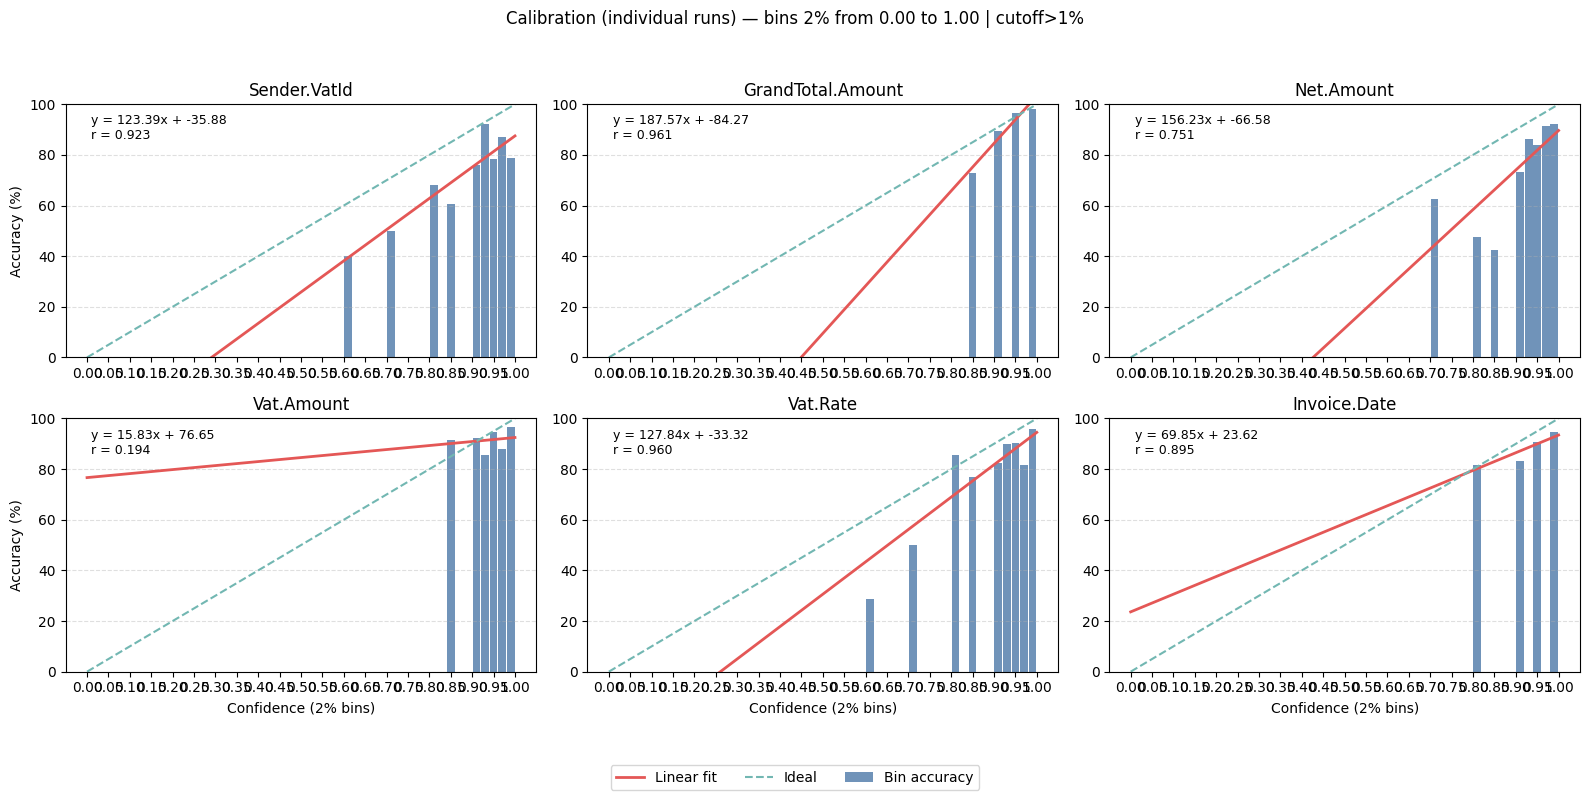

Saved: ..\Output\Hard-3-trace-full\calibration_runs_grid_0_100_2pct_cut1.png


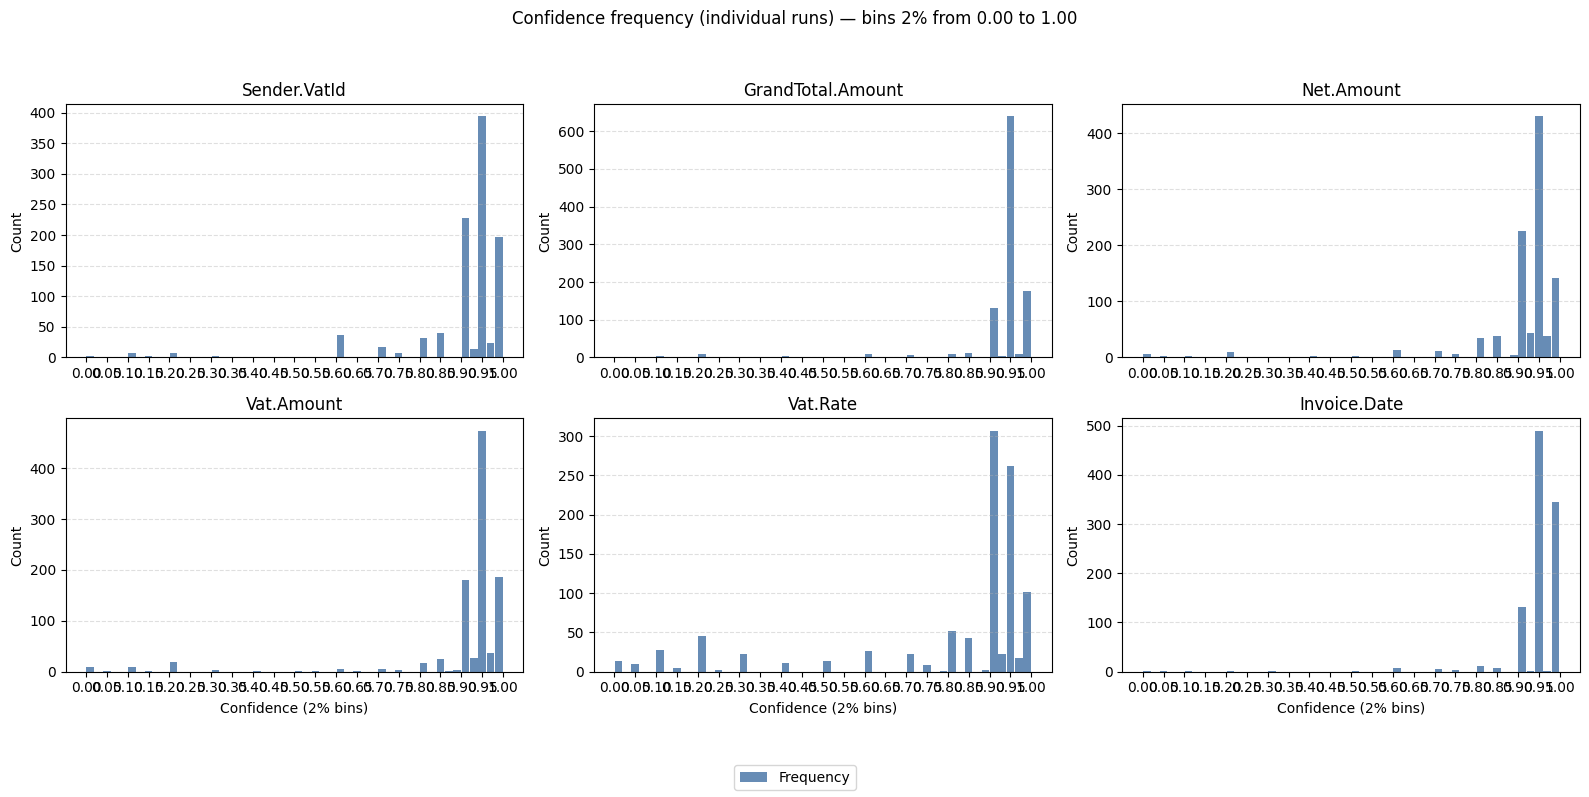

Saved: ..\Output\Hard-3-trace-full\frequency_runs_grid_0_100_2pct.png


In [120]:
# 80–100% in 2% bins
FOLDER_TO_VISUALIZE = "Hard-3-trace-full"
MIN_CONF = 0.0
MAX_CONF = 1.0
BIN_WIDTH = 0.02
MIN_BIN_PCT = 0.01

plot_calibration(f"../Output/{FOLDER_TO_VISUALIZE}", mode="runs",  min_conf=MIN_CONF, max_conf=MAX_CONF, bin_width=BIN_WIDTH, min_bin_pct=MIN_BIN_PCT)
plot_confidence_frequency(f"../Output/{FOLDER_TO_VISUALIZE}", mode="runs", min_conf=MIN_CONF, max_conf=MAX_CONF, bin_width=BIN_WIDTH)

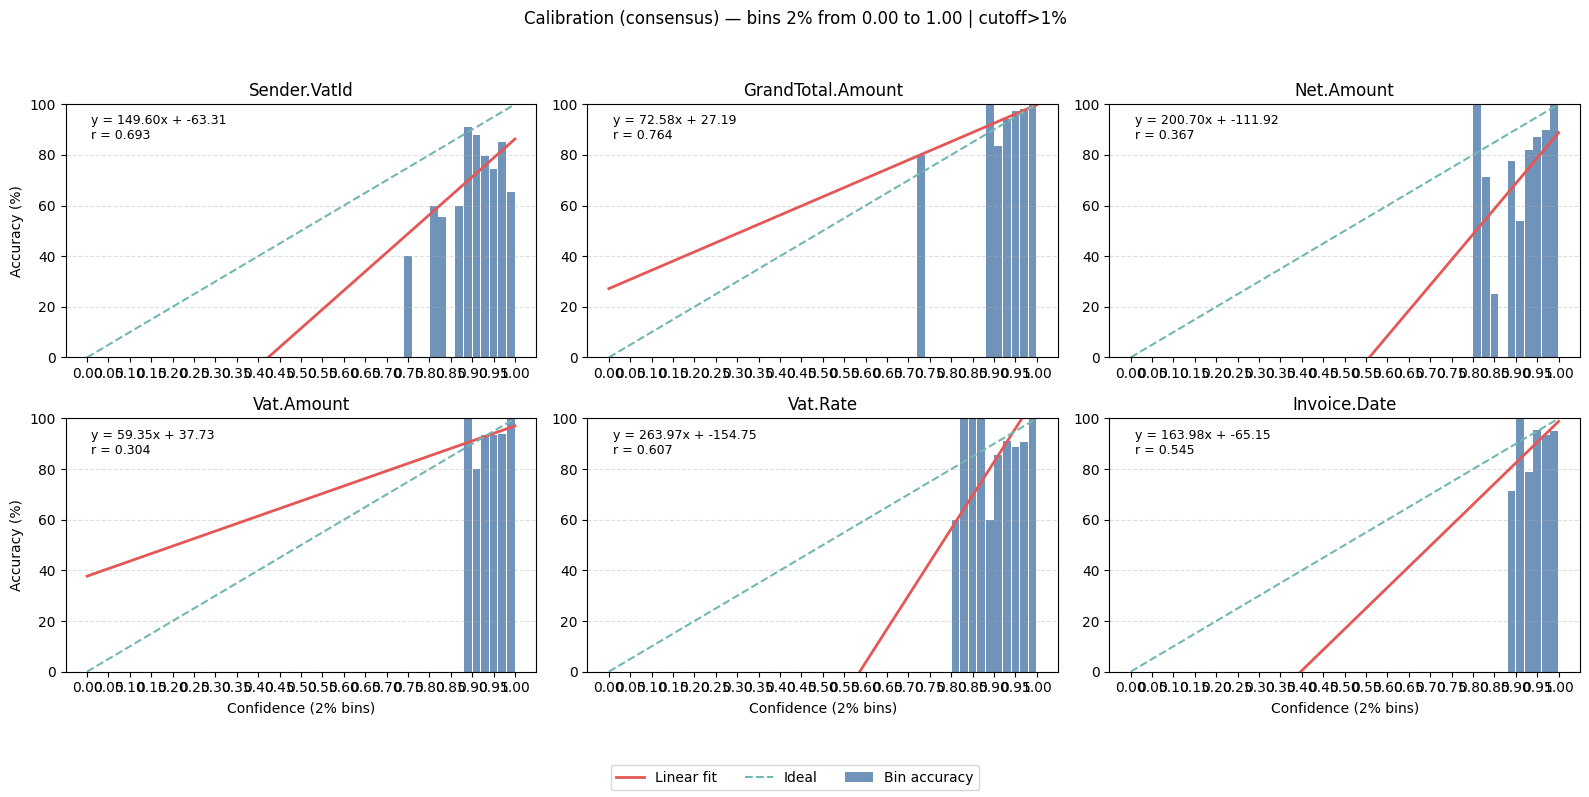

Saved: ..\Output\Hard-3-trace-full\calibration_consensus_grid_0_100_2pct_cut1.png


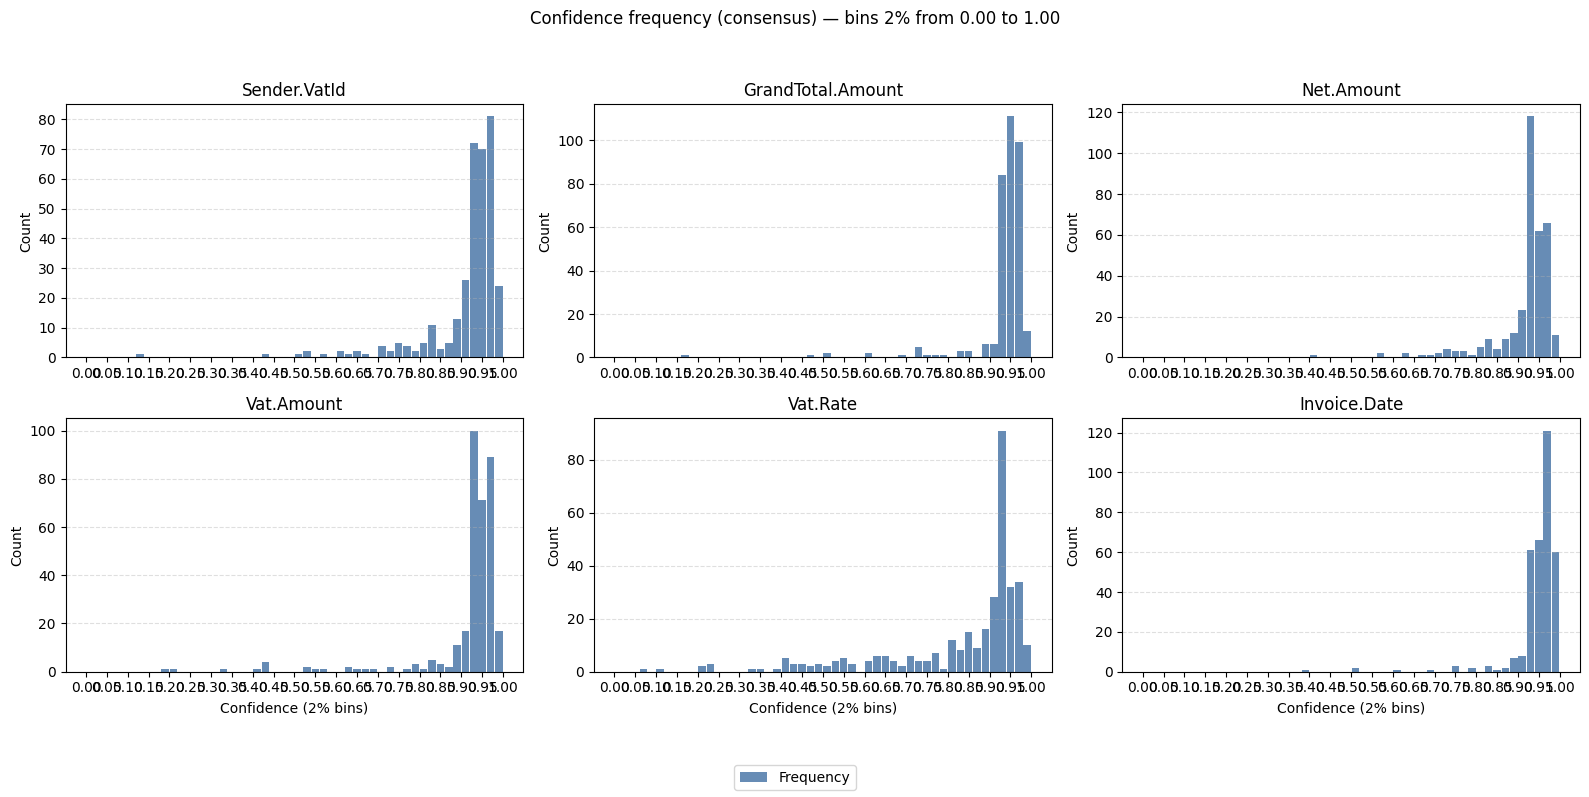

Saved: ..\Output\Hard-3-trace-full\frequency_consensus_grid_0_100_2pct.png


In [121]:
plot_calibration(f"../Output/{FOLDER_TO_VISUALIZE}", mode="consensus",  min_conf=MIN_CONF, max_conf=MAX_CONF, bin_width=BIN_WIDTH, min_bin_pct=MIN_BIN_PCT)
plot_confidence_frequency(f"../Output/{FOLDER_TO_VISUALIZE}", mode="consensus", min_conf=MIN_CONF, max_conf=MAX_CONF, bin_width=BIN_WIDTH)

In [122]:
import json
from pathlib import Path

def print_wrong_consensus(run_dir: str | Path, only_fields: list[str] | None = None):
    run_dir = Path(run_dir)
    assert run_dir.is_dir(), f"Not a directory: {run_dir}"

    consensus_files = sorted(run_dir.glob("*/consensus.json"))
    if not consensus_files:
        print(f"No consensus.json files under {run_dir}")
        return

    total_files = 0
    files_with_errors = 0
    total_errors = 0

    for cf in consensus_files:
        data = json.loads(cf.read_text(encoding="utf-8"))
        input_path = data.get("input_path")
        final_answer = data.get("final_answer", {}) or {}

        # Build flat answer dict and per-field confidence from consensus
        answer_values = {}
        per_field_conf = {}
        for field, entry in final_answer.items():
            if only_fields and field not in only_fields:
                continue
            if isinstance(entry, dict) and "value" in entry:
                answer_values[field] = entry.get("value")
                per_field_conf[field] = entry.get("avg_confidence")
            else:
                answer_values[field] = entry
                per_field_conf[field] = None

        total_files += 1

        # Evaluate vs. ground truth
        evaluation = compare_with_ground_truth(answer_values, input_path)
        per_field_eval = evaluation.get("per_field", {})
        if not per_field_eval:
            # ground truth missing or no comparable fields
            continue

        wrongs = []
        for field, triple in per_field_eval.items():
            try:
                is_match = bool(triple[0])
            except Exception:
                continue
            if not is_match:
                pred_val = answer_values.get(field)
                gt_val = triple[2]
                conf = per_field_conf.get(field)
                wrongs.append((field, pred_val, gt_val, conf))

        if wrongs:
            files_with_errors += 1
            file_id = Path(input_path).stem.split("_")[0] if input_path else cf.parent.name
            print(f"\n=== File {file_id} ===")
            for field, pred, gt, conf in wrongs:
                total_errors += 1
                print(f"- {field}")
                print(f"  predicted: {pred}")
                print(f"  ground_tr: {gt}")
                print(f"  confidence: {conf}")

    print(f"\nScanned: {total_files} files | Files with errors: {files_with_errors} | Total wrong fields: {total_errors}")

# Example:
print_wrong_consensus(f'../Output/{FOLDER_TO_VISUALIZE}')


=== File 158401 ===
- Sender.VatId
  predicted: 02577550342
  ground_tr: IT00098090210
  confidence: 0.9
- Invoice.Date
  predicted: 08/02/2022
  ground_tr: 28/02/2022
  confidence: 0.93

=== File 160208 ===
- Sender.VatId
  predicted: CZ28109       302
  ground_tr: CZ28109902
  confidence: 0.6

=== File 160889 ===
- GrandTotal.Amount
  predicted: 
  ground_tr: 650,00
  confidence: 0.17

=== File 160934 ===
- Sender.VatId
  predicted: ATU62333479
  ground_tr: S169462097
  confidence: 0.93

=== File 160960 ===
- Sender.VatId
  predicted: ATU47239901
  ground_tr: ATU73397567
  confidence: 0.82

=== File 161104 ===
- Sender.VatId
  predicted: 263399.42-2-03
  ground_tr: HU26339942
  confidence: 0.8

=== File 161169 ===
- Sender.VatId
  predicted: DE114406665
  ground_tr: None
  confidence: 0.99

=== File 161171 ===
- Sender.VatId
  predicted: DE114406665
  ground_tr: None
  confidence: 0.98

=== File 161174 ===
- Sender.VatId
  predicted: DE114406665
  ground_tr: None
  confidence: 0.96


# Eval

In [123]:
import json, math
from pathlib import Path
from collections import defaultdict
import numpy as np

def _gather_conf_label_samples(run_dir: str | Path, mode: str):
    run_dir = Path(run_dir)
    assert mode in ("consensus", "runs")
    samples_by_field = defaultdict(list)  # field -> list of (conf, label)

    if mode == "consensus":
        files = sorted(run_dir.glob("*/consensus.json"))
        assert files, f"No consensus.json files under {run_dir}"
        for cf in files:
            try:
                data = json.loads(cf.read_text(encoding="utf-8"))
            except Exception:
                continue
            input_path = data.get("input_path")
            final_answer = data.get("final_answer", {}) or {}
            answer_values, per_field_conf = {}, {}
            for field, entry in final_answer.items():
                if isinstance(entry, dict) and "value" in entry:
                    answer_values[field] = entry.get("value")
                    per_field_conf[field] = entry.get("avg_confidence")
                else:
                    answer_values[field] = entry
                    per_field_conf[field] = None
            evaluation = compare_with_ground_truth(answer_values, input_path)
            for field, triple in (evaluation.get("per_field", {}) or {}).items():
                try:
                    label = 1 if bool(triple[0]) else 0
                    conf = per_field_conf.get(field, None)
                    if conf is None:
                        continue
                    conf = float(conf)
                    if not (0.0 <= conf <= 1.0):
                        continue
                except Exception:
                    continue
                samples_by_field[field].append((conf, label))
    else:
        files = sorted(run_dir.glob("*/*/*.json"))
        if not files:
            print(f"No individual run files under {run_dir}")
            return {}
        for rf in files:
            try:
                data = json.loads(rf.read_text(encoding="utf-8"))
            except Exception:
                continue
            input_path = data.get("input_path")
            answer = data.get("answer", {}) or {}
            conf_map = data.get("confidence_numeric", {}) or {}
            evaluation = compare_with_ground_truth(answer, input_path)
            for field, triple in (evaluation.get("per_field", {}) or {}).items():
                try:
                    label = 1 if bool(triple[0]) else 0
                    conf = conf_map.get(field, None)
                    if conf is None:
                        continue
                    conf = float(conf)
                    if not (0.0 <= conf <= 1.0):
                        continue
                except Exception:
                    continue
                samples_by_field[field].append((conf, label))

    return samples_by_field

def _ece_from_bins(samples, edges: np.ndarray, minc: float, maxc: float):
    # samples: list of (conf, label)
    if not samples:
        return {"ece": None, "bins": []}
    num_bins = len(edges)
    bw = edges[1] - edges[0] if num_bins >= 2 else (maxc - minc)
    def _bin_idx(c):
        c = max(0.0, min(1.0, float(c)))
        if c < minc:
            return None
        if c >= maxc:
            return num_bins - 1 if num_bins > 0 else None
        return int(math.floor((c - minc) / bw)) if bw > 0 else 0

    per_bin = [ {"sum_conf":0.0, "correct":0, "total":0} for _ in range(num_bins) ]
    for conf, label in samples:
        idx = _bin_idx(conf)
        if idx is None:
            continue
        per_bin[idx]["sum_conf"] += conf
        per_bin[idx]["correct"] += int(label)
        per_bin[idx]["total"] += 1

    N = sum(b["total"] for b in per_bin)
    if N == 0:
        return {"ece": None, "bins": []}

    ece = 0.0
    out_bins = []
    for i, b in enumerate(per_bin):
        if b["total"] == 0:
            out_bins.append({"center": float(minc + (i + 0.5) * bw), "acc": None, "conf": None, "n": 0})
            continue
        acc = b["correct"] / b["total"]
        conf_mean = b["sum_conf"] / b["total"]
        w = b["total"] / N
        ece += w * abs(acc - conf_mean)
        out_bins.append({"center": float(minc + (i + 0.5) * bw), "acc": acc, "conf": conf_mean, "n": b["total"]})

    return {"ece": float(ece), "bins": out_bins}

def _roc_auc(scores, labels):
    # returns AUROC or None if undefined
    if not scores:
        return None
    y = np.asarray(labels, dtype=float)
    s = np.asarray(scores, dtype=float)
    P = float((y == 1).sum())
    N = float((y == 0).sum())
    if P == 0 or N == 0:
        return None
    # Sweep thresholds by sorting scores descending
    order = np.argsort(-s, kind="mergesort")
    y_sorted = y[order]
    s_sorted = s[order]

    tps, fps = [0.0], [0.0]
    TP, FP = 0.0, 0.0
    last_score = None
    for i in range(len(s_sorted)):
        if last_score is None or s_sorted[i] != last_score:
            tps.append(TP)
            fps.append(FP)
            last_score = s_sorted[i]
        if y_sorted[i] == 1:
            TP += 1
        else:
            FP += 1
    tps.append(TP); fps.append(FP)

    tpr = np.array(tps) / P
    fpr = np.array(fps) / N
    # Ensure starts at (0,0)
    if fpr[0] != 0 or tpr[0] != 0:
        fpr = np.concatenate([[0.0], fpr])
        tpr = np.concatenate([[0.0], tpr])
    auc = float(np.trapz(tpr, fpr))
    return auc

def _brier(scores, labels):
    if not scores:
        return None
    s = np.asarray(scores, dtype=float)
    y = np.asarray(labels, dtype=float)
    return float(np.mean((s - y) ** 2))

def show_calibration_tables(
    run_dir: str | Path,
    mode: str = "consensus",
    min_conf: float = MIN_CONF,
    max_conf: float = MAX_CONF,
    bin_width: float = BIN_WIDTH,
):
    res = compute_calibration_scores(run_dir, mode=mode, min_conf=min_conf, max_conf=max_conf, bin_width=bin_width)

    # Overall table
    overall = res.get("overall", {}) or {}
    df_overall = pd.DataFrame([overall])[["count", "ece", "brier", "auroc"]]
    df_overall = df_overall.round({"ece": 4, "brier": 4, "auroc": 4})
    print(f"Overall ({mode})")
    display(df_overall)

    # Per-field table
    pf = res.get("per_field", {}) or {}
    rows = []
    for field, m in pf.items():
        rows.append({
            "field": field,
            "count": m.get("count"),
            "ece": m.get("ece"),
            "brier": m.get("brier"),
            "auroc": m.get("auroc"),
        })
    df_fields = pd.DataFrame(rows)[["field", "count", "ece", "brier", "auroc"]].sort_values(by=["field"])
    df_fields = df_fields.round({"ece": 4, "brier": 4, "auroc": 4})
    print(f"Per-field ({mode})")
    display(df_fields)
    
def compute_calibration_scores(
    run_dir: str | Path,
    mode: str = "consensus",  # "consensus" or "runs"
    min_conf: float = 0.0,
    max_conf: float = 1.0,
    bin_width: float = 0.05
):
    run_dir = Path(run_dir)
    assert run_dir.is_dir(), f"Not a directory: {run_dir}"
    assert mode in ("consensus", "runs"), "mode must be 'consensus' or 'runs'"

    samples_by_field = _gather_conf_label_samples(run_dir, mode)
    # overall samples (across fields)
    all_samples = []
    for field, lst in samples_by_field.items():
        all_samples.extend(lst)

    # Bins for ECE
    minc = float(min_conf); maxc = float(max_conf); bw = float(bin_width)
    assert 0.0 <= minc < maxc <= 1.0
    assert bw > 0
    edges = np.arange(minc, maxc, bw)

    # Per-field metrics
    per_field = {}
    for field, lst in samples_by_field.items():
        scores = [c for c, _ in lst]
        labels = [y for _, y in lst]
        ece_info = _ece_from_bins(lst, edges, minc, maxc)
        per_field[field] = {
            "count": len(lst),
            "ece": ece_info["ece"],
            "brier": _brier(scores, labels),
            "auroc": _roc_auc(scores, labels),
        }

    # Overall metrics
    scores_all = [c for (c, _) in all_samples]
    labels_all = [y for (_, y) in all_samples]
    overall = {
        "count": len(all_samples),
        "ece": _ece_from_bins(all_samples, edges, minc, maxc)["ece"],
        "brier": _brier(scores_all, labels_all) if all_samples else None,
        "auroc": _roc_auc(scores_all, labels_all) if all_samples else None,
    }

    result = {
        "mode": mode,
        "range": {"min_conf": minc, "max_conf": maxc, "bin_width": bw},
        "overall": overall,
        "per_field": per_field,
    }
    # Optionally write a JSON summary next to plots
    out_path = run_dir / f"calibration_scores_{mode}_{int(minc*100)}_{int(maxc*100)}_{int(bw*100)}pct.json"
    out_path.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"Saved: {out_path}")
    return result

In [124]:
import pandas as pd
from IPython.display import display
scores_cons = compute_calibration_scores(
    f"../Output/{FOLDER_TO_VISUALIZE}",
    mode="consensus",
    min_conf=MIN_CONF,
    max_conf=MAX_CONF,
    bin_width=BIN_WIDTH,
)

# Individual runs
scores_runs = compute_calibration_scores(
    f"../Output/{FOLDER_TO_VISUALIZE}",
    mode="runs",
    min_conf=MIN_CONF,
    max_conf=MAX_CONF,
    bin_width=BIN_WIDTH,
)

# Consensus
show_calibration_tables(f"../Output/{FOLDER_TO_VISUALIZE}", mode="consensus", min_conf=MIN_CONF, max_conf=MAX_CONF, bin_width=BIN_WIDTH)

# Individual runs
show_calibration_tables(f"../Output/{FOLDER_TO_VISUALIZE}", mode="runs", min_conf=MIN_CONF, max_conf=MAX_CONF, bin_width=BIN_WIDTH)

C:\Users\jonas\AppData\Local\Temp\ipykernel_21636\2564176300.py:147: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = float(np.trapz(tpr, fpr))


Saved: ..\Output\Hard-3-trace-full\calibration_scores_consensus_0_100_2pct.json
Saved: ..\Output\Hard-3-trace-full\calibration_scores_runs_0_100_2pct.json
Saved: ..\Output\Hard-3-trace-full\calibration_scores_consensus_0_100_2pct.json
Overall (consensus)


,count,ece,brier,auroc
0,1642,0.0656,0.1098,0.6766


Per-field (consensus)


,field,count,ece,brier,auroc
1,GrandTotal.Amount,339,0.0357,0.0470,0.8095
5,Invoice.Date,337,0.0636,0.0878,0.6929
2,Net.Amount,262,0.1321,0.1606,0.7109
0,Sender.VatId,314,0.1675,0.2018,0.5824
3,Vat.Amount,257,0.0276,0.0592,0.5941
4,Vat.Rate,133,0.0902,0.1066,0.7022


Saved: ..\Output\Hard-3-trace-full\calibration_scores_runs_0_100_2pct.json
Overall (runs)


C:\Users\jonas\AppData\Local\Temp\ipykernel_21636\2564176300.py:147: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = float(np.trapz(tpr, fpr))


,count,ece,brier,auroc
0,4911,0.0674,0.1114,0.6668


Per-field (runs)


,field,count,ece,brier,auroc
1,GrandTotal.Amount,1014,0.0218,0.0464,0.7799
5,Invoice.Date,1008,0.0516,0.0891,0.6494
2,Net.Amount,784,0.1260,0.1636,0.6729
0,Sender.VatId,940,0.1712,0.2068,0.6038
3,Vat.Amount,768,0.0212,0.0560,0.5967
4,Vat.Rate,397,0.0662,0.1117,0.7165


# Blumatix Scoring

In [125]:
import os, json
from pathlib import Path
from typing import override

load_dotenv(override=True)
BLUMATIX_DIR = Path(os.getenv("BLUMATIX_SCORE_STORAGE"))

# Map BLUMATIX 'TypeName' → our 6 keys
_BLX_TO_OUR = {
    "SenderVatId": "Sender.VatId",
    "GrandTotalAmount": "GrandTotal.Amount",
    "NetTotalAmount": "Net.Amount",
    "VatTotalAmount": "Vat.Amount",
    "VatRate": "Vat.Rate",
    "InvoiceDate": "Invoice.Date",
}

def _coerce_score(x):
    try:
        s = float(x)
    except Exception:
        return None
    if s < 0:  # they sometimes use -1.0 for N/A
        return 0
    return max(0.0, min(1.0, s))

def _clean_value(v):
    # prefer "Value"; fall back to "Text"
    if isinstance(v, dict):
        val = v.get("Value", None)
        if val in (None, ""):
            val = v.get("Text", None)
        return val
    return v

def extract_blumatix_fields_from_file(path: str | Path) -> dict:
    """
    Returns:
      {
        "file_id": "164039",
        "values": { "Sender.VatId": "...", ... },
        "scores": { "Sender.VatId": 0.99, ... }
      }
    """
    p = Path(path)
    try:
        data = json.loads(p.read_text(encoding="utf-8"))
    except Exception:
        return None

    values = {}
    scores = {}

    # 1) Flat predictions
    for item in (data.get("InvoiceDetailTypePredictions") or []):
        tname = item.get("TypeName")
        our = _BLX_TO_OUR.get(tname)
        if not our:
            continue
        val = _clean_value(item)
        if isinstance(val, dict):
            v = _clean_value(val)
        else:
            v = item.get("Value") or item.get("Text")
        values[our] = v
        scores[our] = _coerce_score(item.get("Score"))

    # 2) Groups (e.g., VatGroup.VatRate)
    for grp in (data.get("PredictionGroups") or []):
        for item in (grp.get("InvoiceDetailTypePredictions") or []):
            tname = item.get("TypeName")
            our = _BLX_TO_OUR.get(tname)
            if not our:
                continue
            # Only fill if not already filled by flat predictions
            if our not in values or values[our] in (None, ""):
                v = item.get("Value") or item.get("Text")
                values[our] = v
                scores[our] = _coerce_score(item.get("Score"))

    return {
        "file_id": p.stem,
        "values": values,
        "scores": scores,
    }

def load_blumatix_batch(directory: str | Path | None = None) -> list[dict]:
    """Load all *.json under BLUMATIX_DIR (or provided directory)."""
    base = Path(directory) if directory else BLUMATIX_DIR
    assert base and base.is_dir(), f"Not a folder: {base}"
    out = []
    for fp in sorted(base.glob("*.json")):
        rec = extract_blumatix_fields_from_file(fp)
        if rec:
            out.append(rec)
    return out


from collections import defaultdict

def _guess_input_txt_path_from_id(file_id: str) -> Path | None:
    # Reuse your existing GT lookup: you only need the .json next to the original txt.
    # If your GT helper (_gt_path_for_txt) relies on a txt path, we synthesize a path-like with the id.
    # We assume your Documents/<id>/ has the GT json. We'll scan for any *_grid_concat.txt to pass into compare.
    docs = Path(DOCUMENT_STORAGE)  # adjust if needed
    cand_dir = docs / file_id
    if not cand_dir.is_dir():
        return None
    # pick any *_grid_concat.txt as the anchor; compare_with_ground_truth only uses id to find GT json
    txts = sorted(cand_dir.glob(f"{file_id}*_grid_concat.txt"))
    return txts[0] if txts else None

def gather_blumatix_samples(directory: str | Path | None = None):
    """
    Returns samples_by_field: field -> list of (score, label)
    """
    recs = load_blumatix_batch(directory)
    samples = defaultdict(list)
    for rec in recs:
        fid = rec["file_id"]
        vals = rec["values"]
        scs = rec["scores"]
        txt_path = _guess_input_txt_path_from_id(fid)
        if not txt_path:
            continue
        eval_res = compare_with_ground_truth(vals, txt_path)

        for field, triple in (eval_res.get("per_field", {}) or {}).items():
            label = 1 if bool(triple[0]) else 0
            score = scs.get(field)
            if score is None:
                continue
            samples[field].append((float(score), int(label)))
    return samples

import numpy as np
import matplotlib.pyplot as plt

def plot_blumatix_calibration(
    directory: str | Path | None = None,
    min_conf: float = MIN_CONF,
    max_conf: float = MAX_CONF,
    bin_width: float = BIN_WIDTH,
    min_bin_pct: float = MIN_BIN_PCT,
):
    samples = gather_blumatix_samples(directory)
    edges, centers, labels, num_bins, bw, minc, maxc = _make_bins(min_conf, max_conf, bin_width)

    # accumulate bin stats
    stats = {f: [ {"correct":0,"total":0} for _ in range(num_bins) ] for f in COMPARE_FIELDS}
    for field, lst in samples.items():
        for conf, label in lst:
            idx = _bin_index_conf(conf, edges, minc, maxc, bw, num_bins)
            if idx is None:
                continue
            stats[field][idx]["total"] += 1
            stats[field][idx]["correct"] += int(label)

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()

    for ax_idx, field in enumerate(COMPARE_FIELDS):
        ax = axes[ax_idx]
        bin_counts = stats.get(field, [ {"correct":0,"total":0} for _ in range(num_bins) ])
        total_for_field = sum(c["total"] for c in bin_counts) or 1

        x_conf, y_acc, acc_pct = [], [], []
        for i in range(num_bins):
            c = bin_counts[i]
            frac = (c["total"] / total_for_field)
            if c["total"] > 0 and frac > min_bin_pct:
                acc = 100.0 * c["correct"] / c["total"]
                acc_pct.append(acc)
                x_conf.append(float(centers[i]))
                y_acc.append(acc)
            else:
                acc_pct.append(np.nan)

        ax.bar(centers, acc_pct, width=bw*0.9, color="#4C78A8", alpha=0.8, label="Bin accuracy")

        if len(x_conf) >= 2 and len(set(x_conf)) > 1:
            m, b0 = np.polyfit(np.array(x_conf), np.array(y_acc), 1)
            x_line = np.linspace(minc, maxc, 100)
            y_line = m * x_line + b0
            ax.plot(x_line, y_line, color="#E45756", linewidth=2, label="Linear fit")
            r = float(np.corrcoef(np.array(x_conf), np.array(y_acc))[0,1])
            ax.text(minc + 0.01*(maxc-minc), 96, f"y={m:.2f}x+{b0:.2f}\nr={r:.3f}",
                    va="top", ha="left", fontsize=9,
                    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=3))

        x_ref = np.linspace(minc, maxc, 100)
        ax.plot(x_ref, 100.0*x_ref, color="#72B7B2", linestyle="--", linewidth=1.5, label="Ideal")

        ax.set_ylim(0, 100)
        ax.set_title(field)
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        tick_step = 0.05
        xt = np.arange(minc, maxc + 1e-9, tick_step)
        xlbl = [f"{t:.2f}" for t in xt]
        ax.set_xticks(xt, xlbl)
        if ax_idx % 3 == 0:
            ax.set_ylabel("Accuracy (%)")
        if ax_idx >= 3:
            ax.set_xlabel(f"Score ({int(bw*100)}% bins)")

    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc="lower center", ncol=3)
    fig.suptitle(f"BLUMATIX calibration — bins {int(bw*100)}% from {minc:.2f} to {maxc:.2f}")
    fig.tight_layout(rect=[0, 0.08, 1, 0.95])
    out_path = (Path(directory) if directory else BLUMATIX_DIR) / f"blumatix_calibration_{int(minc*100)}_{int(maxc*100)}_{int(bw*100)}pct.png"
    fig.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved: {out_path}")

def plot_blumatix_frequency(
    directory: str | Path | None = None,
    min_conf: float = MIN_CONF,
    max_conf: float = MAX_CONF,
    bin_width: float = BIN_WIDTH,
):
    samples = gather_blumatix_samples(directory)
    edges, centers, labels, num_bins, bw, minc, maxc = _make_bins(min_conf, max_conf, bin_width)
    freq = {f: [0 for _ in range(num_bins)] for f in COMPARE_FIELDS}
    for field, lst in samples.items():
        for conf, _ in lst:
            idx = _bin_index_conf(conf, edges, minc, maxc, bw, num_bins)
            if idx is not None:
                freq[field][idx] += 1

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()
    for ax_idx, field in enumerate(COMPARE_FIELDS):
        ax = axes[ax_idx]
        ax.bar(centers, freq.get(field, [0]*num_bins), width=bw*0.9, color="#4C78A8", alpha=0.85, label="Frequency")
        ax.set_title(field); ax.set_ylabel("Count")
        tick_step = 0.05
        xt = np.arange(minc, maxc + 1e-9, tick_step)
        xlbl = [f"{t:.2f}" for t in xt]
        ax.set_xticks(xt, xlbl)
        if ax_idx >= 3:
            ax.set_xlabel(f"Score ({int(bw*100)}% bins)")
        ax.grid(axis="y", linestyle="--", alpha=0.4)

    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc="lower center", ncol=3)
    fig.suptitle(f"BLUMATIX score frequency — bins {int(bw*100)}% from {minc:.2f} to {maxc:.2f}")
    fig.tight_layout(rect=[0, 0.08, 1, 0.95])
    out_path = (Path(directory) if directory else BLUMATIX_DIR) / f"blumatix_frequency_{int(minc*100)}_{int(maxc*100)}_{int(bw*100)}pct.png"
    fig.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved: {out_path}")

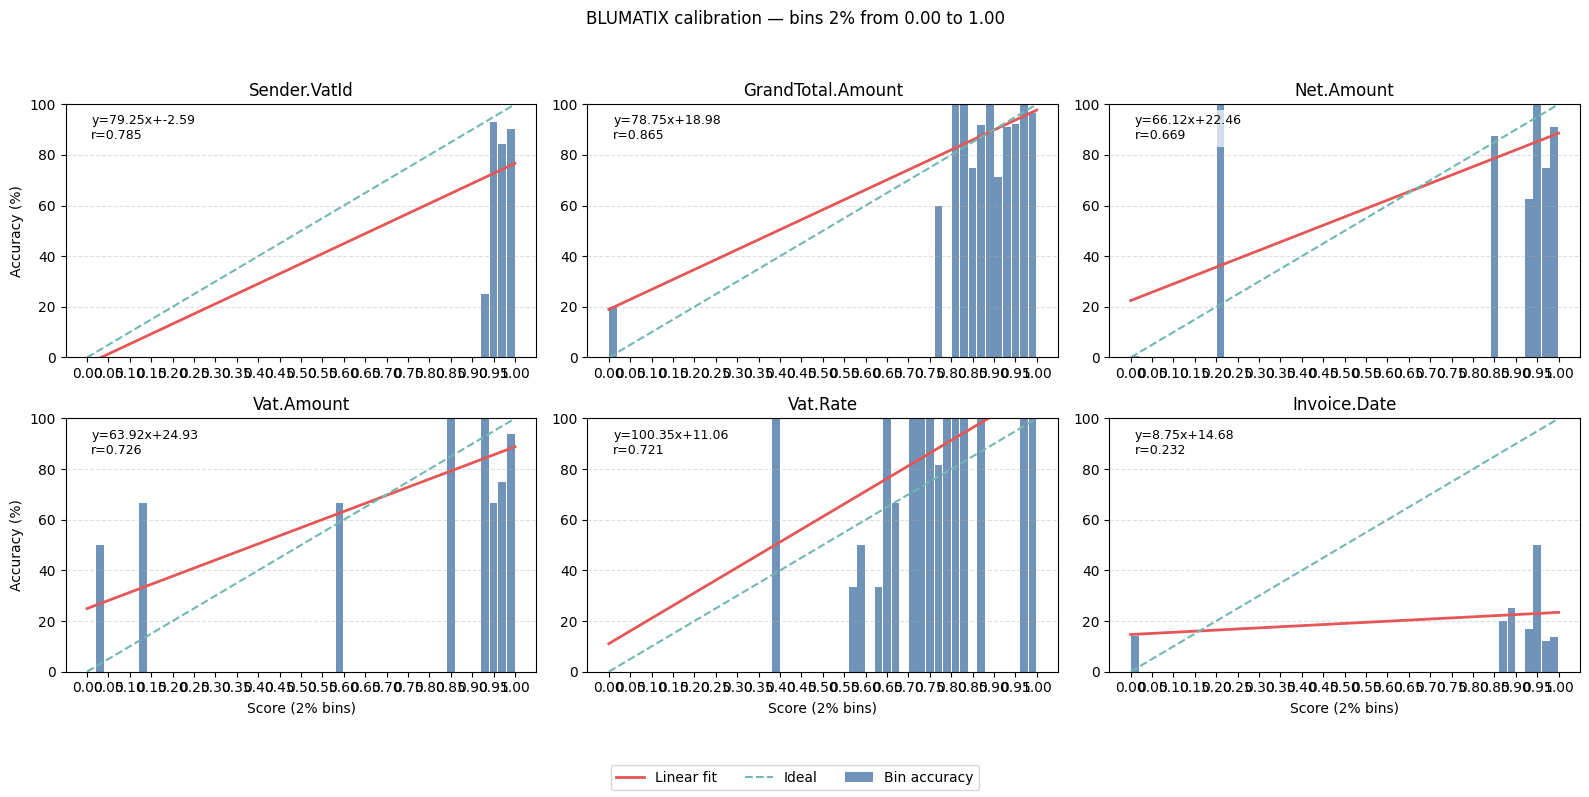

Saved: \\nas-01\TrainingsDataExt4\steady-faster-learning\confidence_score\prod_predictions\blumatix_calibration_0_100_2pct.png


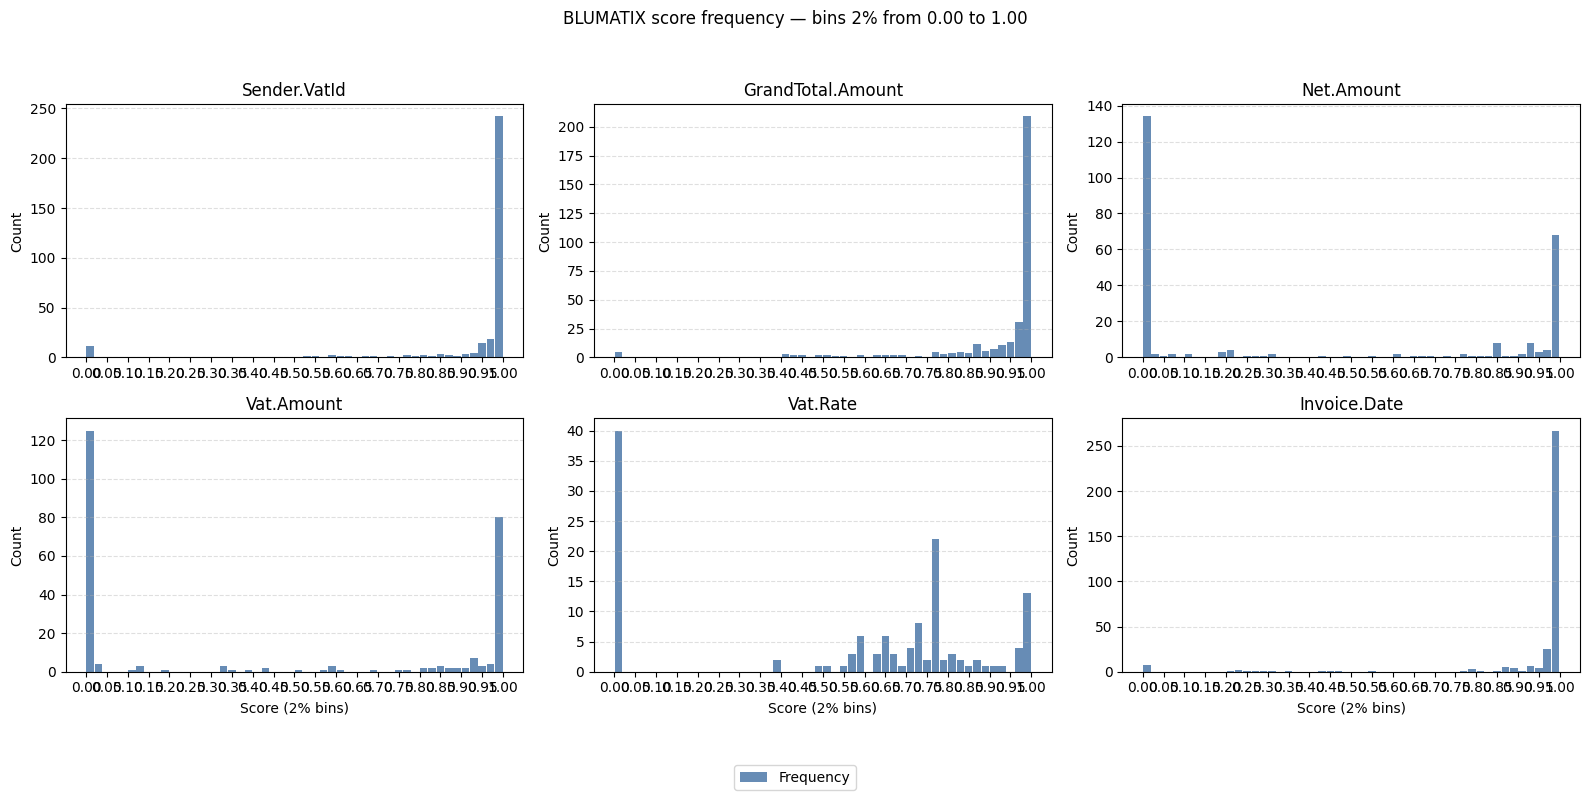

Saved: \\nas-01\TrainingsDataExt4\steady-faster-learning\confidence_score\prod_predictions\blumatix_frequency_0_100_2pct.png


In [126]:
# Use BLUMATIX_SCORE_STORAGE by default
plot_blumatix_calibration(min_conf=MIN_CONF, max_conf=MAX_CONF, bin_width=BIN_WIDTH, min_bin_pct=MIN_BIN_PCT)
plot_blumatix_frequency(min_conf=MIN_CONF, max_conf=MAX_CONF, bin_width=BIN_WIDTH)